In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install adjustText
from adjustText import adjust_text
from google.colab import drive
drive.mount("/content/drive")
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats

Mounted at /content/drive


In [2]:
wine_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/STA437/wine_quality/wine_quality_data.csv")
# Separate features, target, and wine type
feature_cols = ['fixed_acidity', 'volatile_acidity', 'citric_acid',
'residual_sugar', 'chlorides', 'free_sulfur_dioxide',
'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol']
X = wine_df[feature_cols]
quality = wine_df['quality']
wine_type = wine_df['wine_type']
print(f"Total samples: {len(wine_df)}")
print(f"Wine type distribution:\n{wine_df['wine_type'].value_counts()}")

Total samples: 6497
Wine type distribution:
wine_type
white    4898
red      1599
Name: count, dtype: int64


Quick data audit

In [3]:
predictor_cols = [
    "fixed_acidity",
    "volatile_acidity",
    "citric_acid",
    "residual_sugar",
    "chlorides",
    "free_sulfur_dioxide",
    "total_sulfur_dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol",
]
target_col = "quality"
group_col = "wine_type"


print("Shape:", wine_df.shape)
print("\nWine type counts:")
print(wine_df[group_col].value_counts(dropna=False))

print("\nMissing values (nonzero only):")
na = wine_df[predictor_cols + [target_col, group_col]].isna().sum()
print(na[na > 0].sort_values(ascending=False))

print("\nDuplicated rows:", int(wine_df.duplicated().sum()))

print("\nQuality summary:")
print(wine_df[target_col].describe())

print("\nNumeric ranges (min/max) for predictors:")
ranges = wine_df[predictor_cols].agg(["min", "max"]).T
print(ranges)

Shape: (6497, 13)

Wine type counts:
wine_type
white    4898
red      1599
Name: count, dtype: int64

Missing values (nonzero only):
Series([], dtype: int64)

Duplicated rows: 1177

Quality summary:
count    6497.000000
mean        5.818378
std         0.873255
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         9.000000
Name: quality, dtype: float64

Numeric ranges (min/max) for predictors:
                          min        max
fixed_acidity         3.80000   15.90000
volatile_acidity      0.08000    1.58000
citric_acid           0.00000    1.66000
residual_sugar        0.60000   65.80000
chlorides             0.00900    0.61100
free_sulfur_dioxide   1.00000  289.00000
total_sulfur_dioxide  6.00000  440.00000
density               0.98711    1.03898
pH                    2.72000    4.01000
sulphates             0.22000    2.00000
alcohol               8.00000   14.90000


remove duplicated rows for the following analysis

In [4]:
wine_df = wine_df.drop_duplicates(keep="first").reset_index(drop=True)

print("New shape:", wine_df.shape)


New shape: (5320, 13)


univariate distribution for each variable

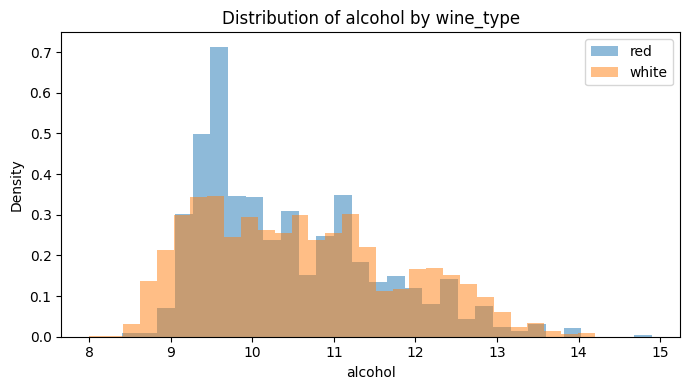

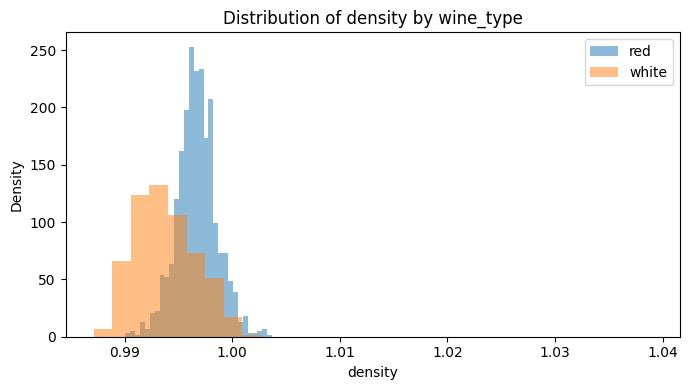

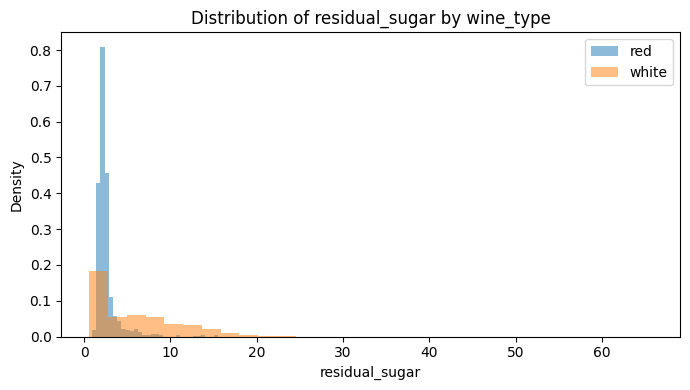

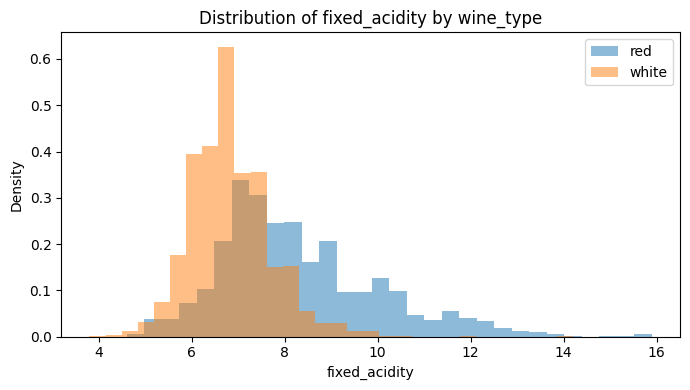

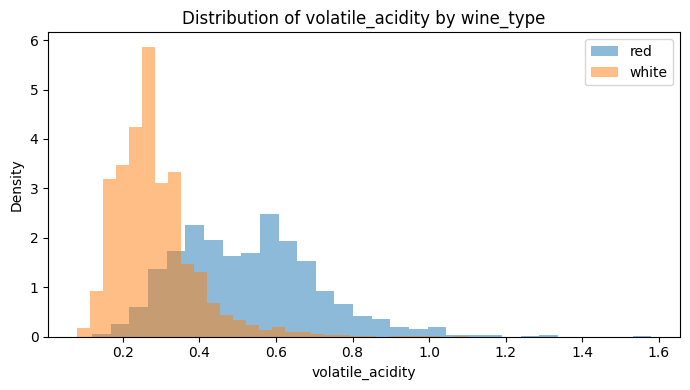

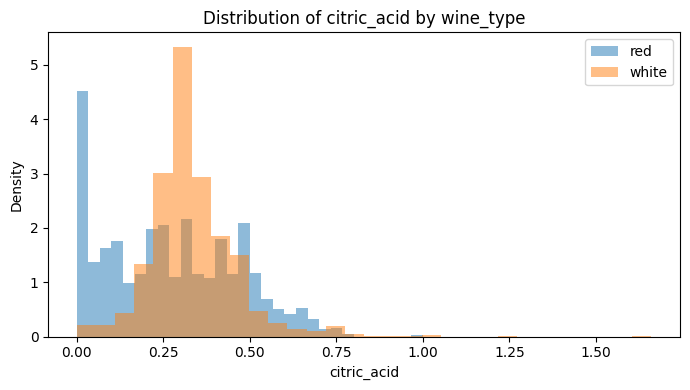

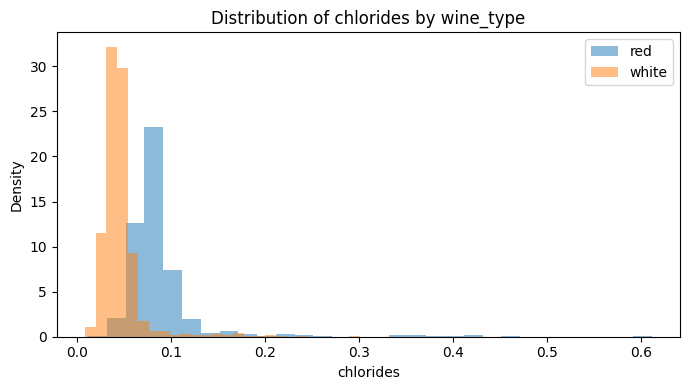

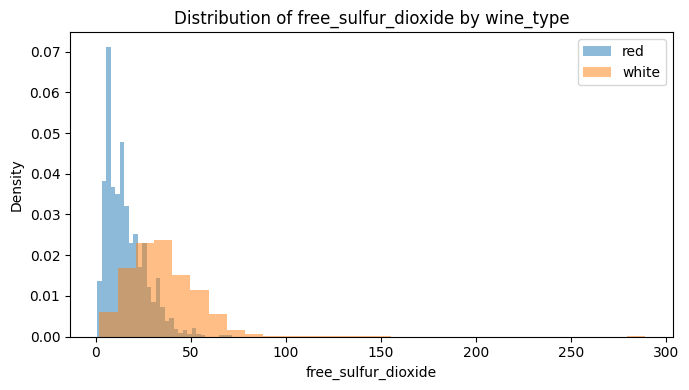

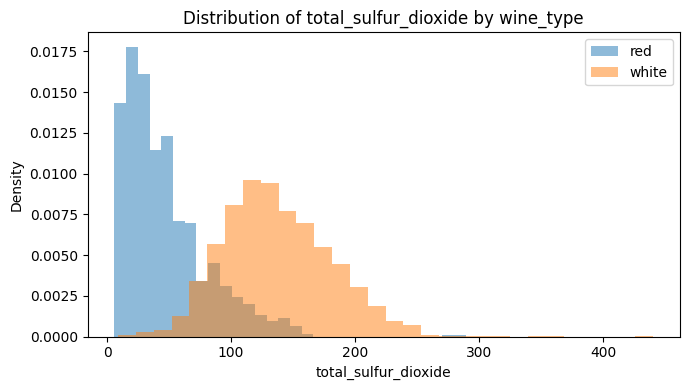

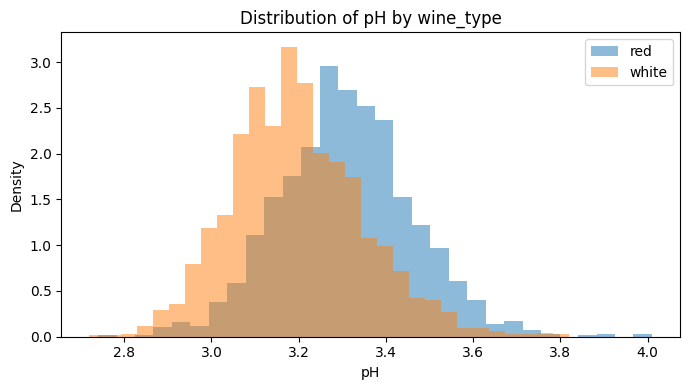

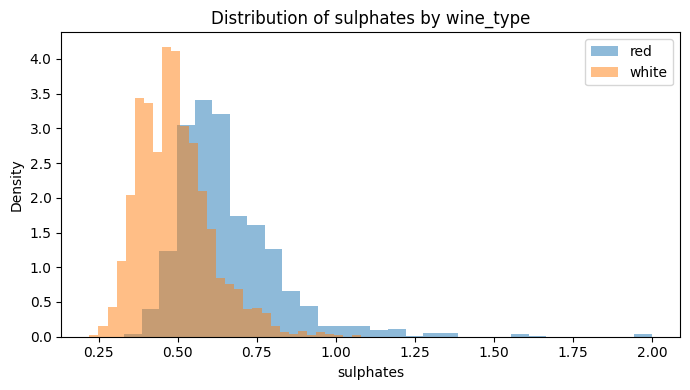

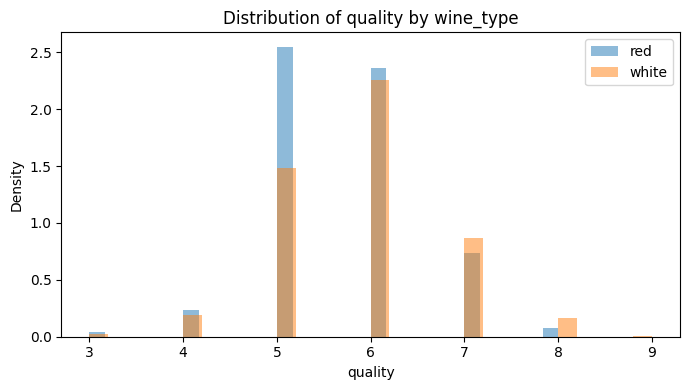

In [ ]:
plot_vars = ["alcohol", "density", "residual_sugar", "fixed_acidity", "volatile_acidity", "citric_acid", "chlorides", "free_sulfur_dioxide", "total_sulfur_dioxide", "pH", "sulphates", "quality" ]

types = sorted(wine_df[group_col].dropna().unique(), key=lambda x: str(x))

for v in plot_vars:
    plt.figure(figsize=(7, 4))
    for t in types:
        x = wine_df.loc[wine_df[group_col] == t, v].dropna()
        plt.hist(x, bins=30, alpha=0.5, density=True, label=str(t))
    plt.title(f"Distribution of {v} by {group_col}")
    plt.xlabel(v)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


correlation matrix

correlation within each wine type

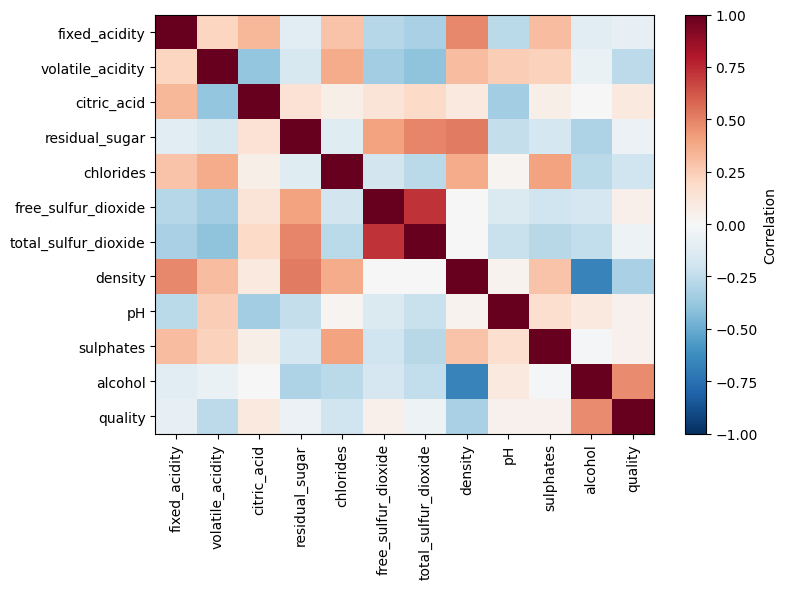

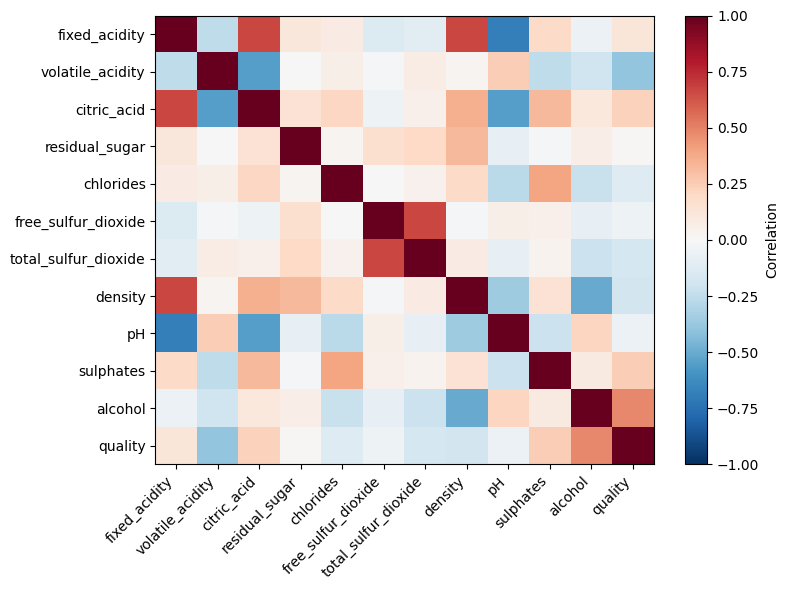

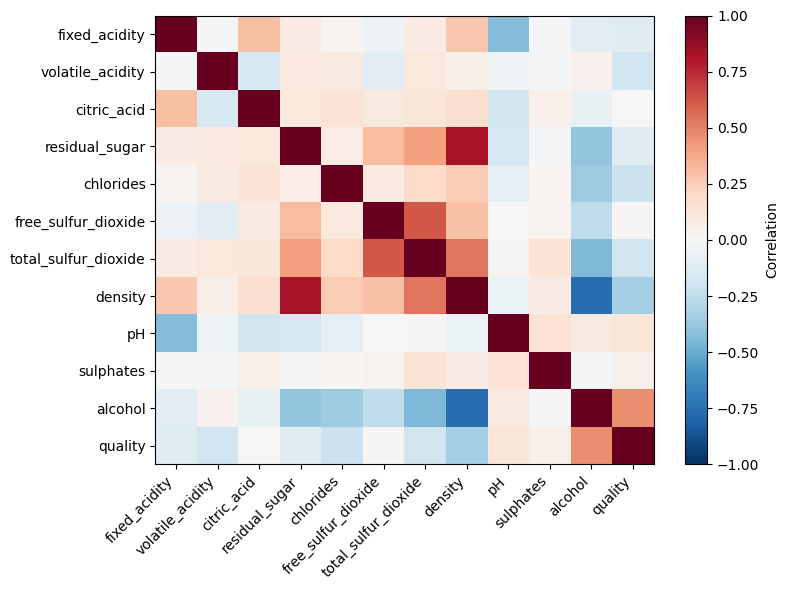

In [ ]:
# numeric columns to include
cols = [c for c in wine_df.columns if pd.api.types.is_numeric_dtype(wine_df[c])]
# ensure quality is included and wine_type excluded
cols = [c for c in cols if c != "wine_type"]
# Pearson correlation
corr_all = wine_df[cols].corr(method="pearson")

plt.figure(figsize=(8,6))
plt.imshow(corr_all, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(cols)), cols, rotation=90)
plt.yticks(range(len(cols)), cols)
plt.tight_layout()
plt.show()

# Stratified (if wine_type exists)
if "wine_type" in wine_df.columns:
    for t, g in wine_df.groupby("wine_type"):
        corr_t = g[cols].corr(method="pearson")
        plt.figure(figsize=(8,6))
        plt.imshow(corr_t, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
        plt.colorbar(label="Correlation")
        plt.xticks(range(len(cols)), cols, rotation=45, ha="right")
        plt.yticks(range(len(cols)), cols)
        plt.tight_layout()
        plt.show()

In [ ]:
# print full matrix (rounded)
print("Overall correlation matrix (Pearson):")
print(corr_all.round(3).to_string())

# print correlations with quality only (sorted)
print("\nCorrelations with quality (Pearson), sorted by |corr|:")
q = corr_all["quality"].drop("quality").sort_values(key=lambda s: s.abs(), ascending=False)
print(q.round(3).to_string())

Overall correlation matrix (Pearson):
                      fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  free_sulfur_dioxide  total_sulfur_dioxide  density     pH  sulphates  alcohol  quality
fixed_acidity                 1.000             0.215        0.330          -0.104      0.289               -0.282                -0.327    0.478 -0.271      0.305   -0.103   -0.080
volatile_acidity              0.215             1.000       -0.384          -0.164      0.368               -0.349                -0.401    0.308  0.247      0.228   -0.065   -0.265
citric_acid                   0.330            -0.384        1.000           0.146      0.055                0.131                 0.195    0.095 -0.345      0.059   -0.005    0.098
residual_sugar               -0.104            -0.164        0.146           1.000     -0.123                0.399                 0.488    0.521 -0.235     -0.175   -0.305   -0.057
chlorides                     0.289             0.36

In [ ]:
# Red and white correlation matrices (Pearson)
corr_red   = wine_df.loc[wine_df["wine_type"] == "red", cols].corr(method="pearson")
corr_white = wine_df.loc[wine_df["wine_type"] == "white", cols].corr(method="pearson")

print("Red wine correlation matrix (Pearson):")
print(corr_red.round(3).to_string())

print("\nWhite wine correlation matrix (Pearson):")
print(corr_white.round(3).to_string())

# If you mainly care about how quality relates within each type:
print("\nRed: correlations with quality (sorted by |corr|):")
q_red = corr_red["quality"].drop("quality").sort_values(key=lambda s: s.abs(), ascending=False)
print(q_red.round(3).to_string())

print("\nWhite: correlations with quality (sorted by |corr|):")
q_white = corr_white["quality"].drop("quality").sort_values(key=lambda s: s.abs(), ascending=False)
print(q_white.round(3).to_string())

Red wine correlation matrix (Pearson):
                      fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  free_sulfur_dioxide  total_sulfur_dioxide  density     pH  sulphates  alcohol  quality
fixed_acidity                 1.000            -0.255        0.667           0.111      0.086               -0.141                -0.104    0.670 -0.687      0.190   -0.062    0.119
volatile_acidity             -0.255             1.000       -0.551          -0.002      0.055               -0.021                 0.072    0.024  0.247     -0.257   -0.198   -0.395
citric_acid                   0.667            -0.551        1.000           0.144      0.210               -0.048                 0.047    0.358 -0.550      0.326    0.105    0.228
residual_sugar                0.111            -0.002        0.144           1.000      0.027                0.161                 0.201    0.325 -0.083     -0.012    0.063    0.014
chlorides                     0.086             0.0

check outliers

                            mean        std      min      25%        50%  \
residual_sugar          5.048477   4.500180  0.60000   1.8000    2.70000   
chlorides               0.056690   0.036863  0.00900   0.0380    0.04700   
free_sulfur_dioxide    30.036654  17.805045  1.00000  16.0000   28.00000   
total_sulfur_dioxide  114.109023  56.774223  6.00000  74.0000  116.00000   
volatile_acidity        0.344130   0.168248  0.08000   0.2300    0.30000   
citric_acid             0.318494   0.147157  0.00000   0.2400    0.31000   
sulphates               0.533357   0.149743  0.22000   0.4300    0.51000   
fixed_acidity           7.215179   1.319671  3.80000   6.4000    7.00000   
alcohol                10.549241   1.185933  8.00000   9.5000   10.40000   
pH                      3.224664   0.160379  2.72000   3.1100    3.21000   
density                 0.994535   0.002966  0.98711   0.9922    0.99465   

                            75%        max       IQR      range        CV  
residual_su

/tmp/ipython-input-682464217.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([wine_df[c].dropna().values for c in predictor_cols], labels=predictor_cols, vert=True)


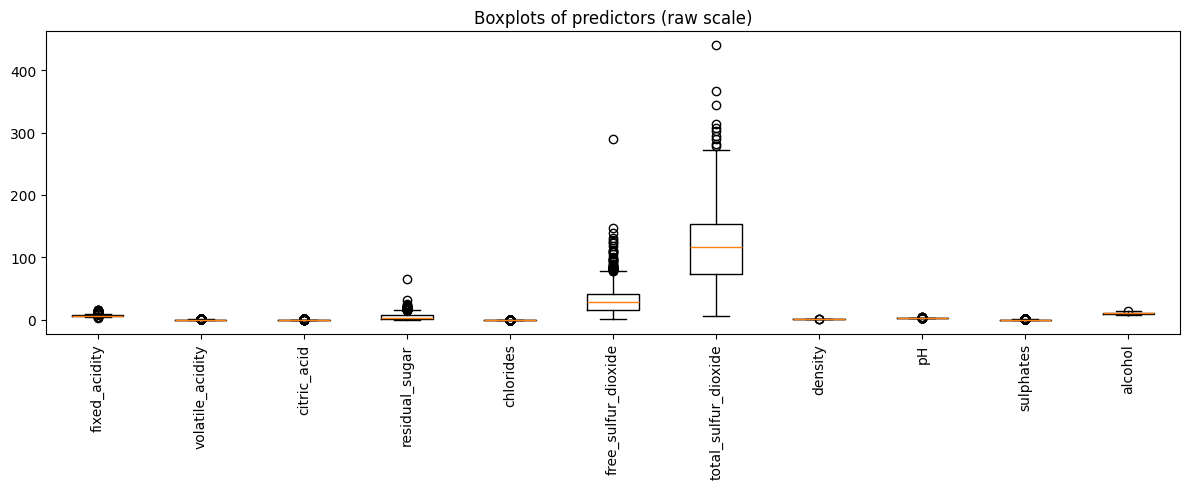

In [ ]:
desc = wine_df[predictor_cols].describe().T  # count, mean, std, min, 25%, 50%, 75%, max
desc["IQR"] = desc["75%"] - desc["25%"]
desc["range"] = desc["max"] - desc["min"]
desc["CV"] = desc["std"] / desc["mean"]  # relative spread; ignore if mean ~ 0
desc = desc[["mean","std","min","25%","50%","75%","max","IQR","range","CV"]]
print(desc.sort_values("CV", ascending=False))

plt.figure(figsize=(12, 5))
plt.boxplot([wine_df[c].dropna().values for c in predictor_cols], labels=predictor_cols, vert=True)
plt.xticks(rotation=90)
plt.title("Boxplots of predictors (raw scale)")
plt.tight_layout()
plt.show()

/tmp/ipython-input-2619501506.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([Z[c].dropna().values for c in predictor_cols], labels=predictor_cols, vert=True)


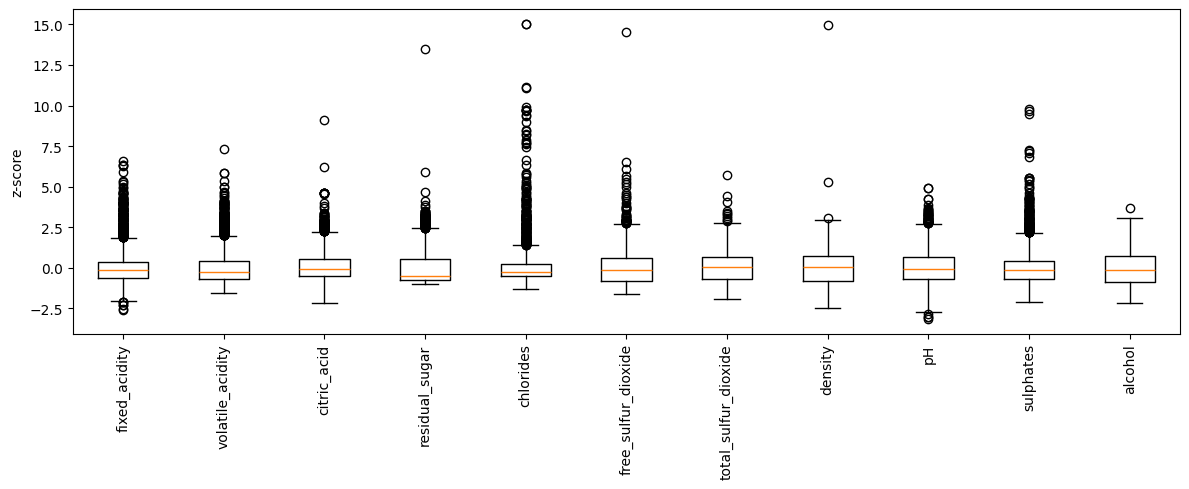

In [ ]:
# Standardized view (so spread/outliers are comparable across variables)
X = wine_df[predictor_cols].copy()
Z = (X - X.mean()) / X.std(ddof=0)

plt.figure(figsize=(12, 5))
plt.boxplot([Z[c].dropna().values for c in predictor_cols], labels=predictor_cols, vert=True)
plt.xticks(rotation=90)
plt.ylabel("z-score")
plt.tight_layout()
plt.show()

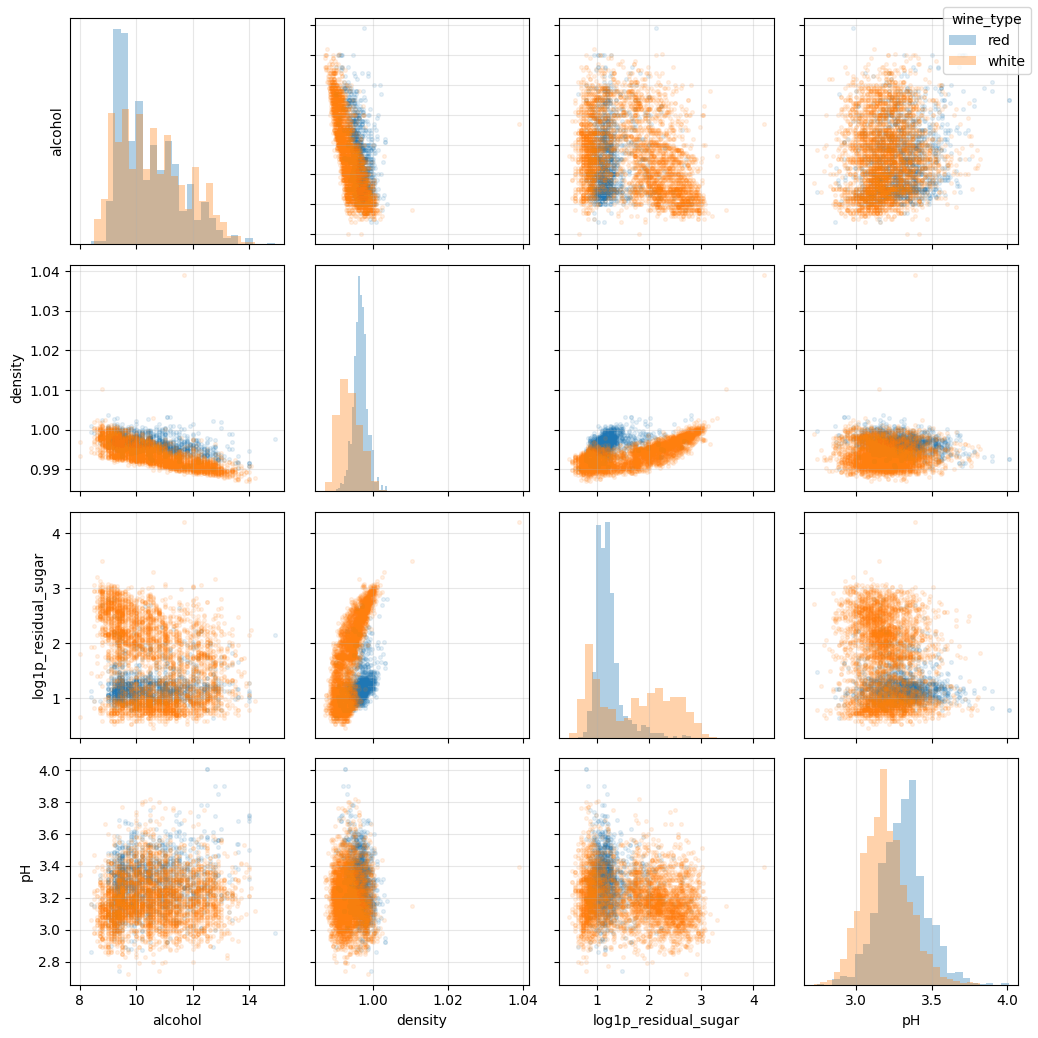

In [ ]:
vars_to_plot = ["alcohol", "density", "residual_sugar", "pH", "volatile_acidity"]  # edit as you like
types = sorted(wine_df[group_col].dropna().unique(), key=lambda x: str(x))

vars_to_plot = ["alcohol", "density", "residual_sugar", "pH"]  # 4–6 max recommended
group_col = "wine_type"
types = sorted(wine_df[group_col].dropna().unique(), key=lambda x: str(x))

def cornerplot_full(
    df,
    vars_list,
    group_col,
    bins=25,
    alpha_scatter=0.12,
    point_size=8,
    alpha_hist=0.35,
    figsize_scale=2.6,
    grid=True,
):
    k = len(vars_list)
    fig, axes = plt.subplots(
        k, k,
        figsize=(figsize_scale * k, figsize_scale * k),
        sharex="col",
        sharey=False
    )

    for i in range(k):
        for j in range(k):
            ax = axes[i, j]
            xvar, yvar = vars_list[j], vars_list[i]

            if grid:
                ax.grid(True, alpha=0.3)

            if i == j:
                # diagonal: density histogram by group
                for t in types:
                    x = df.loc[df[group_col] == t, xvar].dropna().values
                    ax.hist(x, bins=bins, density=True, alpha=alpha_hist, label=str(t))
                ax.set_yticks([])

            else:
                # BOTH triangles: scatter by group
                for t in types:
                    sub = df.loc[df[group_col] == t, [xvar, yvar]].dropna()
                    ax.scatter(sub[xvar], sub[yvar], s=point_size, alpha=alpha_scatter, label=str(t))

            # Clean labels (only outer)
            if i == k - 1:
                ax.set_xlabel(xvar)
            else:
                ax.set_xlabel("")
                ax.tick_params(axis="x", labelbottom=False)

            if j == 0:
                ax.set_ylabel(yvar)
            else:
                ax.set_ylabel("")
                ax.tick_params(axis="y", labelleft=False)

    # One legend
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", frameon=True, title=group_col)

    fig.tight_layout()
    plt.show()



dfp = wine_df.copy()
dfp["log1p_residual_sugar"] = np.log1p(dfp["residual_sugar"])

vars_to_plot = ["alcohol", "density", "log1p_residual_sugar", "pH"]
cornerplot_full(
    dfp,
    vars_to_plot,
    "wine_type",
    alpha_scatter=0.10,
    point_size=7,
    alpha_hist=0.35,
    grid=True
)


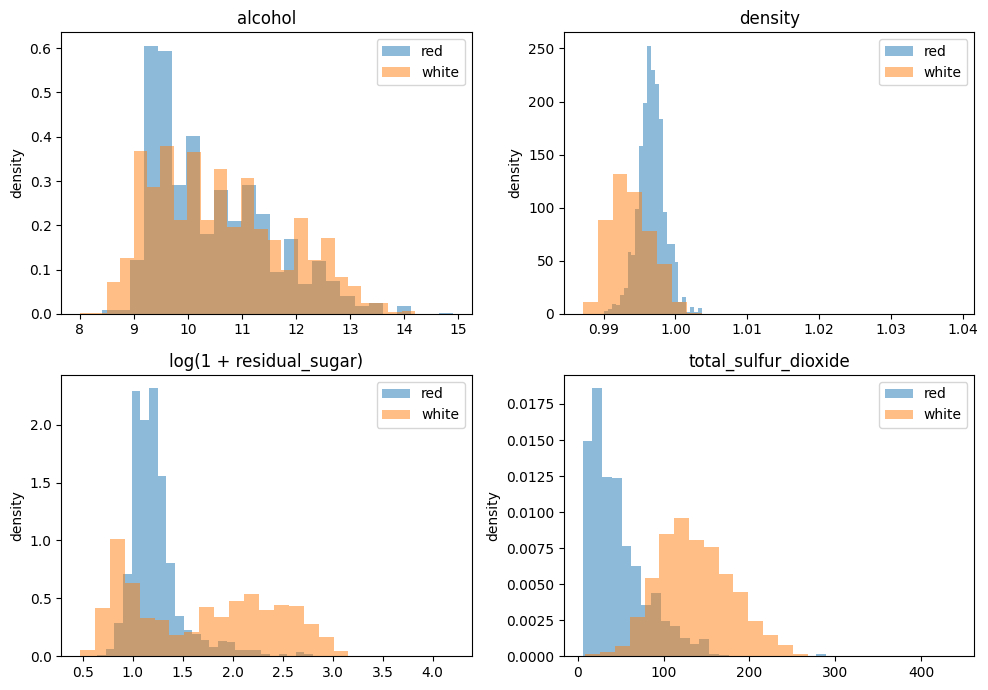

In [ ]:
dfp = wine_df.copy()
dfp["log1p_residual_sugar"] = np.log1p(dfp["residual_sugar"])

vars_hist = ["alcohol", "density", "log1p_residual_sugar", "total_sulfur_dioxide"]
titles = ["alcohol", "density", "log(1 + residual_sugar)", "total_sulfur_dioxide"]
types = ["red", "white"]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.ravel()

for ax, v, ttl in zip(axes, vars_hist, titles):
    for t in types:
        x = dfp.loc[dfp["wine_type"] == t, v].dropna()
        ax.hist(x, bins=25, alpha=0.5, density=True, label=t)
    ax.set_title(ttl)
    ax.set_ylabel("density")
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
exclude_cols = {"quality", "wine_type"}
num_cols = [
    c for c in wine_df.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(wine_df[c])
]

X = wine_df[num_cols].copy()

scaler = StandardScaler()
Xz = scaler.fit_transform(X)
idx_kept = X.index

# Fit PCA
pca = PCA()
scores = pca.fit_transform(Xz)

# Explained variance
explained_var = pca.explained_variance_
explained_ratio = pca.explained_variance_ratio_
cum_ratio = np.cumsum(explained_ratio)

ev_df = pd.DataFrame({
    "PC": np.arange(1, len(num_cols) + 1),
    "eigenvalue": explained_var,
    "prop_var": explained_ratio,
    "cum_prop_var": cum_ratio
})

# Loadings: columns are PCs, rows are variables
loadings = pd.DataFrame(
    pca.components_.T,
    index=num_cols,
    columns=[f"PC{i}" for i in range(1, len(num_cols) + 1)]
)

# Scores dataframe for plotting
scores_df = pd.DataFrame(
    scores[:, :5],  # keep first few PCs for convenience
    index=idx_kept,
    columns=[f"PC{i}" for i in range(1, 6)]
)

# Add wine_type back for coloring in plots if it exists
if "wine_type" in wine_df.columns:
    scores_df["wine_type"] = wine_df.loc[idx_kept, "wine_type"].values

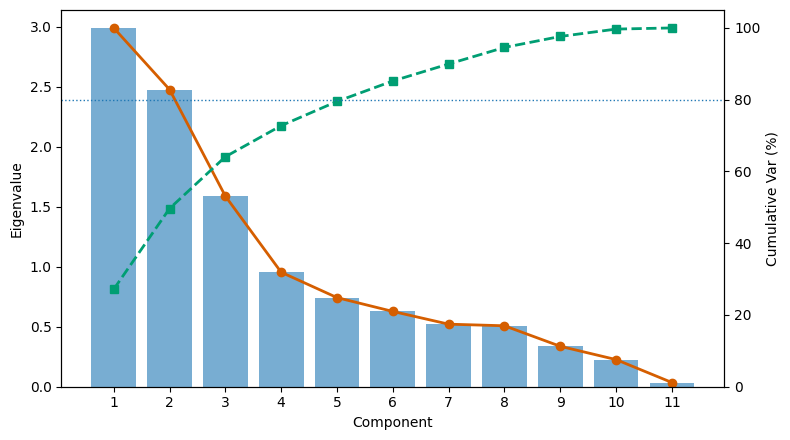

In [ ]:
eigs = pca.explained_variance_                      # eigenvalues
cum = np.cumsum(pca.explained_variance_ratio_) * 100  # cumulative variance (%)

k = len(eigs)
x = np.arange(1, k + 1)

fig, ax1 = plt.subplots(figsize=(8, 4.5))

# bars (eigenvalues)
ax1.bar(x, eigs, alpha=0.6)
# red eigenvalue line
ax1.plot(x, eigs, marker="o", linewidth=2, color="#D55E00")
ax1.set_xlabel("Component")
ax1.set_ylabel("Eigenvalue")
ax1.set_xticks(x)

# second axis: cumulative variance
ax2 = ax1.twinx()
ax2.plot(x, cum, marker="s", linestyle="--", linewidth=2, color="#009E73")
ax2.set_ylabel("Cumulative Var (%)")
ax2.set_ylim(0, 105)

# optional: reference line (e.g., 80% cumulative variance)
target = 80
ax2.axhline(target, linestyle=":", linewidth=1)
# optional label
# ax2.text(1, target + 1, f"{target}%", va="bottom")

plt.tight_layout()
plt.show()

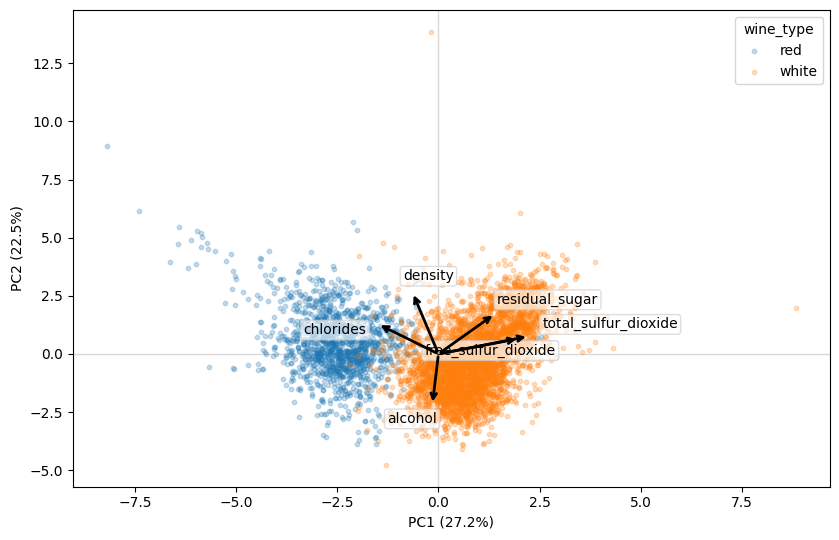

In [ ]:
# scores DF for plotting
scores_df = pd.DataFrame(scores[:, :2], columns=["PC1", "PC2"], index=idx_kept)
if "wine_type" in wine_df.columns:
    scores_df["wine_type"] = wine_df.loc[idx_kept, "wine_type"].astype(str).values

# loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=num_cols,
    columns=[f"PC{i}" for i in range(1, len(num_cols) + 1)]
)

pc1_pct = pca.explained_variance_ratio_[0] * 100
pc2_pct = pca.explained_variance_ratio_[1] * 100

# 2) Plot score scatter
fig, ax = plt.subplots(figsize=(8.5, 5.5))

if "wine_type" in scores_df.columns:
    for t, g in scores_df.groupby("wine_type"):
        ax.scatter(g["PC1"], g["PC2"], s=10, alpha=0.25, label=t, zorder=1)
    ax.legend(title="wine_type", loc="upper right", frameon=True)
else:
    ax.scatter(scores_df["PC1"], scores_df["PC2"], s=10, alpha=0.25, zorder=1)

ax.axhline(0, color="0.85", lw=1, zorder=0)
ax.axvline(0, color="0.85", lw=1, zorder=0)

ax.set_xlabel(f"PC1 ({pc1_pct:.1f}%)")
ax.set_ylabel(f"PC2 ({pc2_pct:.1f}%)")

# 3) Pick top K loading directions (combined magnitude on PC1/PC2)
top_k = 6
w = loadings[["PC1", "PC2"]].copy()
w["strength"] = np.sqrt(w["PC1"]**2 + w["PC2"]**2)
top = w.sort_values("strength", ascending=False).head(top_k)

# 4) Scale arrows to plot range
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
arrow_scale = 0.25  # reduce if too crowded
L = arrow_scale * min(x_max - x_min, y_max - y_min)

# 5) Place labels first, repel them away from each other AND arrow tips
texts = []
tips_x, tips_y = [], []

for var, row in top.iterrows():
    dx, dy = row["PC1"] * L, row["PC2"] * L
    tips_x.append(dx); tips_y.append(dy)

    txt = ax.text(
        dx * 1.10, dy * 1.10, var,
        fontsize=10, ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.8", alpha=0.65),
        zorder=4
    )
    texts.append(txt)

adjust_text(
    texts, ax=ax,
    x=tips_x, y=tips_y,                     # repel away from arrow tips
    expand_text=(1.2, 1.2),
    expand_points=(2.0, 2.0),
    force_text=0.6,
    force_points=0.8,
    arrowprops=dict(arrowstyle="-", color="0.6", lw=0.8)
)

# 6) Draw arrows last so labels never cover them
for var, row in top.iterrows():
    dx, dy = row["PC1"] * L, row["PC2"] * L
    ax.annotate(
        "",
        xy=(dx, dy), xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", lw=2, color="black"),
        zorder=6
    )

plt.tight_layout()
plt.show()

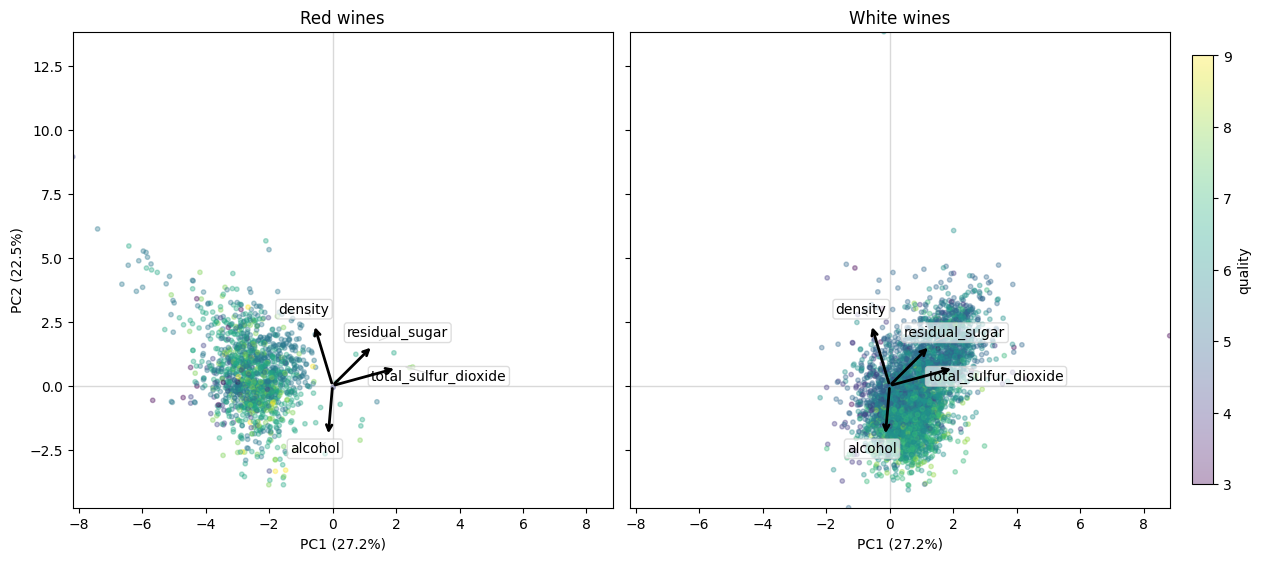

In [ ]:
types = sorted(scores_df["wine_type"].unique())

# use constrained_layout so matplotlib reserves space for the colorbar
fig, axes = plt.subplots(
    1, len(types),
    figsize=(12.5, 5.5),
    sharex=True, sharey=True,
    constrained_layout=True
)
if len(types) == 1:
    axes = [axes]

# consistent limits across facets
x_min, x_max = scores_df["PC1"].min(), scores_df["PC1"].max()
y_min, y_max = scores_df["PC2"].min(), scores_df["PC2"].max()

# arrow scaling based on global limits
arrow_scale = 0.25
L = arrow_scale * min(x_max - x_min, y_max - y_min)

sc_handle = None

for ax, t in zip(axes, types):
    g = scores_df[scores_df["wine_type"] == t]

    sc_handle = ax.scatter(
        g["PC1"], g["PC2"],
        c=g["quality"], s=10, alpha=0.35,
        zorder=1
    )

    ax.axhline(0, color="0.85", lw=1, zorder=0)
    ax.axvline(0, color="0.85", lw=1, zorder=0)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # cleaner facet titles
    ax.set_title("Red wines" if t.lower() == "red" else "White wines")
    ax.set_xlabel(f"PC1 ({pc1_pct:.1f}%)")

    # arrows + labels (same in each facet)
    texts = []
    tips_x, tips_y = [], []
    for var, row in top.iterrows():
        dx, dy = row["PC1"] * L, row["PC2"] * L
        tips_x.append(dx); tips_y.append(dy)

        txt = ax.text(
            dx * 1.10, dy * 1.10, var,
            fontsize=10, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.8", alpha=0.65),
            zorder=4
        )
        texts.append(txt)

    adjust_text(
        texts, ax=ax,
        x=tips_x, y=tips_y,
        expand_text=(1.2, 1.2),
        expand_points=(2.0, 2.0),
        force_text=0.6,
        force_points=0.8,
        arrowprops=dict(arrowstyle="-", color="0.6", lw=0.8)
    )

    for var, row in top.iterrows():
        dx, dy = row["PC1"] * L, row["PC2"] * L
        ax.annotate(
            "",
            xy=(dx, dy), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", lw=2, color="black"),
            zorder=6
        )

axes[0].set_ylabel(f"PC2 ({pc2_pct:.1f}%)")

# put colorbar in its own reserved area (far right), no overlap
cbar = fig.colorbar(sc_handle, ax=axes, location="right", shrink=0.9, pad=0.02)
cbar.set_label("quality")

plt.show()

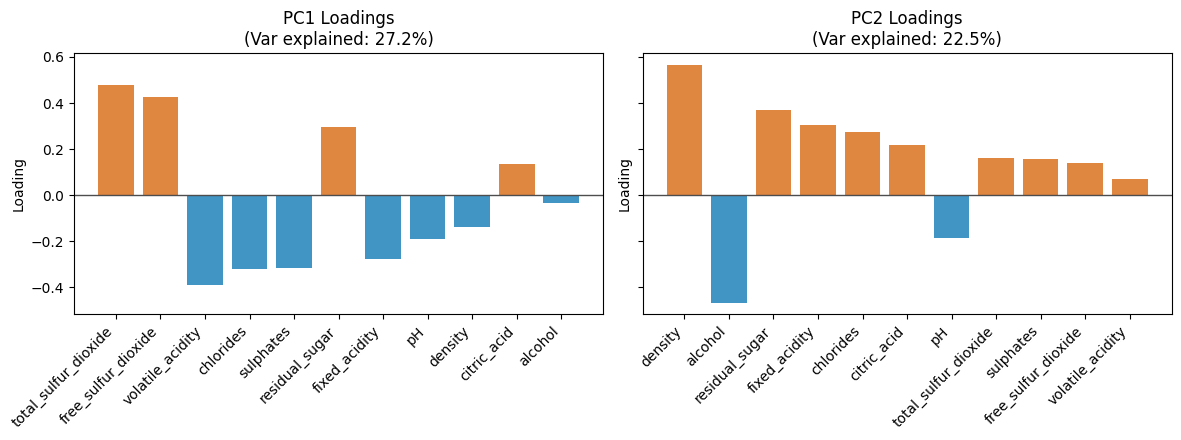

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=num_cols,
    columns=[f"PC{i}" for i in range(1, len(num_cols)+1)]
)

def plot_loading_bars(loadings_df, pc, ax, var_explained):
    s = loadings_df[pc].sort_values(key=lambda x: x.abs(), ascending=False)

    colors = np.where(s.values >= 0, "#D55E00", "#0072B2")  # pos / neg, colorblind-friendly
    ax.bar(range(len(s)), s.values, color=colors, alpha=0.75)
    ax.axhline(0, color="0.3", linewidth=1)
    ax.set_xticks(range(len(s)))
    ax.set_xticklabels(s.index, rotation=45, ha="right")
    ax.set_ylabel("Loading")
    ax.set_title(f"{pc} Loadings\n(Var explained: {var_explained:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

plot_loading_bars(loadings, "PC1", axes[0], pca.explained_variance_ratio_[0]*100)
plot_loading_bars(loadings, "PC2", axes[1], pca.explained_variance_ratio_[1]*100)

plt.tight_layout()
plt.show()

MVN Test

In [6]:

def mardia_test(X: np.ndarray):
    """
    Mardia's multivariate normality test (skewness + kurtosis).
    Returns test statistics and approximate p-values.

    References for approximations:
    - Skewness: b1,p ~ chi-square with df = p(p+1)(p+2)/6
    - Kurtosis: standardized z ~ N(0,1)
    """
    X = np.asarray(X, dtype=float)
    X = X[~np.isnan(X).any(axis=1)]  # drop rows with any NaN
    n, p = X.shape

    if n <= p + 1:
        raise ValueError(f"Need more rows than columns for Mardia test. Got n={n}, p={p}.")

    # center
    Xc = X - X.mean(axis=0, keepdims=True)

    # sample covariance and its inverse
    S = np.cov(Xc, rowvar=False, bias=False)
    Sinv = np.linalg.inv(S)

    # squared Mahalanobis distances
    # d_i^2 = x_i' S^{-1} x_i
    di2 = np.einsum("ij,jk,ik->i", Xc, Sinv, Xc)

    # matrix of pairwise Mahalanobis inner-products: a_ij = x_i' S^{-1} x_j
    A = Xc @ Sinv @ Xc.T

    # Mardia skewness
    b1p = np.mean(A**3)

    # Mardia kurtosis
    b2p = np.mean(di2**2)

    # Approximate p-values
    df_skew = p * (p + 1) * (p + 2) // 6
    chi_skew = n * b1p / 6.0
    p_skew = 1.0 - stats.chi2.cdf(chi_skew, df=df_skew)

    # Kurtosis z approximation
    # mean = p(p+2), var = 8p(p+2)/n
    mean_k = p * (p + 2)
    var_k = (8.0 * p * (p + 2)) / n
    z_kurt = (b2p - mean_k) / np.sqrt(var_k)
    p_kurt = 2.0 * (1.0 - stats.norm.cdf(abs(z_kurt)))

    return {
        "n": n,
        "p": p,
        "skewness_b1p": b1p,
        "skewness_chi2": chi_skew,
        "skewness_df": int(df_skew),
        "skewness_pvalue": p_skew,
        "kurtosis_b2p": b2p,
        "kurtosis_z": z_kurt,
        "kurtosis_pvalue": p_kurt,
    }

X = wine_df[predictor_cols].astype(float).to_numpy()
X = stats.zscore(X, axis=0, nan_policy="omit")  # standardize columns

res = mardia_test(X)
print(pd.Series(res))

n                   5320.000000
p                     11.000000
skewness_b1p         109.020169
skewness_chi2      96664.550106
skewness_df          286.000000
skewness_pvalue        0.000000
kurtosis_b2p         445.066705
kurtosis_z           651.396861
kurtosis_pvalue        0.000000
dtype: float64


repeat PCA on the entire dataset to check the robustness

In [4]:
wine_full = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/STA437/wine_quality/wine_quality_data.csv")

In [5]:
exclude = ["wine_type", "quality"]
X = wine_full.drop(columns=[c for c in exclude if c in wine_full.columns])
X = X.select_dtypes(include=[np.number]).dropna()

scaler = StandardScaler()
Xz = scaler.fit_transform(X)

pca = PCA()
scores = pca.fit_transform(Xz)

eigs = pca.explained_variance_
pve = pca.explained_variance_ratio_
cum_pve = np.cumsum(pve)

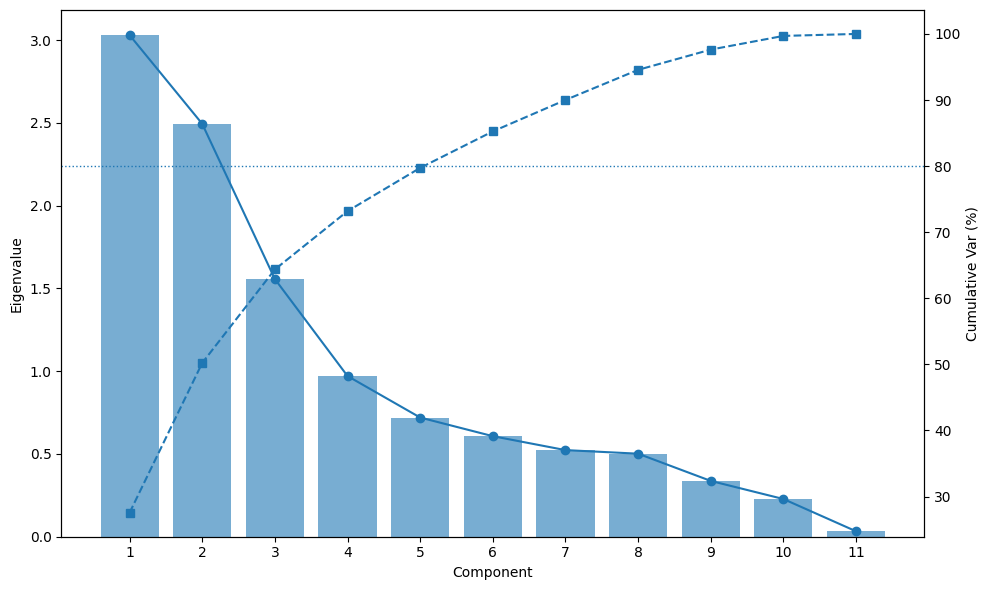

In [6]:
k = len(eigs)
x = np.arange(1, k + 1)

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(x, eigs, alpha=0.6)
ax1.plot(x, eigs, marker="o")
ax1.set_xlabel("Component")
ax1.set_ylabel("Eigenvalue")
ax1.set_xticks(x)

ax2 = ax1.twinx()
ax2.plot(x, cum_pve * 100, marker="s", linestyle="--")
ax2.set_ylabel("Cumulative Var (%)")

ax2.axhline(80, linestyle=":", linewidth=1)

plt.tight_layout()
plt.show()

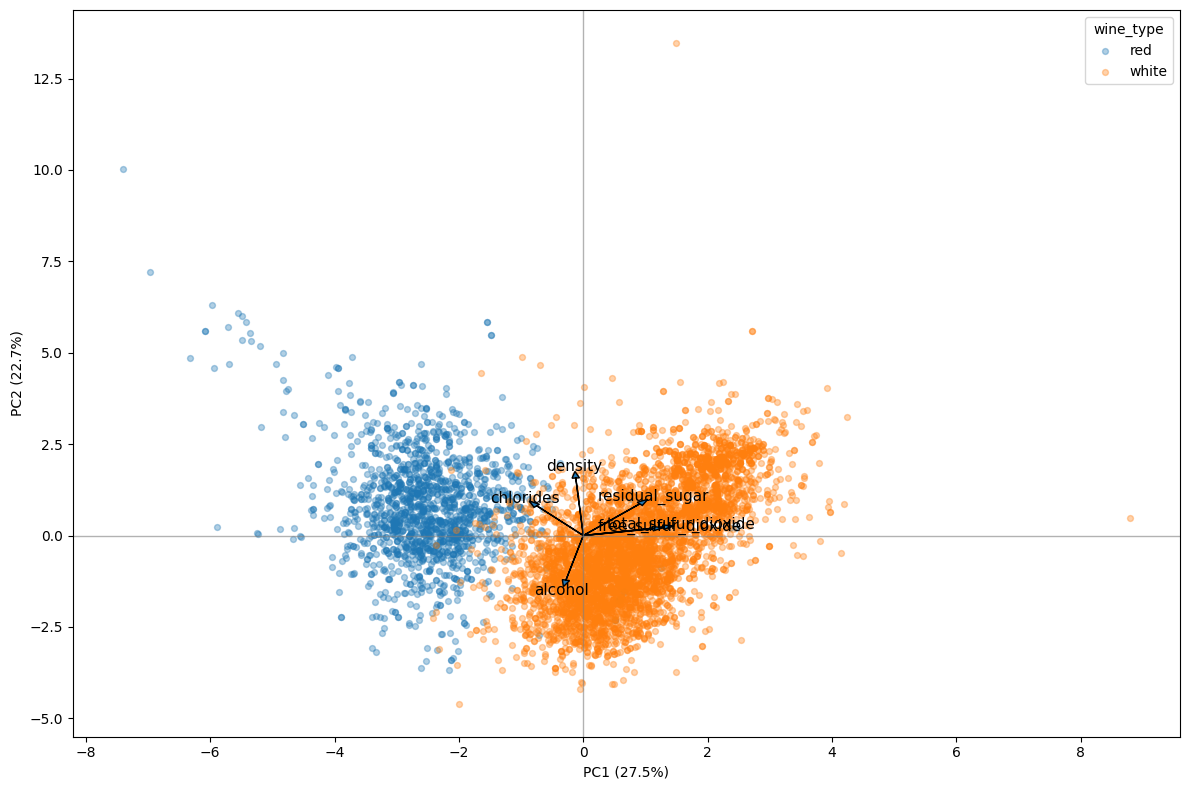

In [7]:
if "wine_type" not in wine_full.columns:
    raise ValueError("wine_type column not found (needed only for coloring the score plot).")

scores_df = pd.DataFrame(scores[:, :2], columns=["PC1", "PC2"])
scores_df["wine_type"] = wine_full.loc[X.index, "wine_type"].astype(str).values  # align with X after dropna

loadings = pca.components_.T
loadings_df = pd.DataFrame(loadings[:, :2], index=X.columns, columns=["PC1", "PC2"])

fig, ax = plt.subplots(figsize=(12, 8))

for t, g in scores_df.groupby("wine_type"):
    ax.scatter(g["PC1"], g["PC2"], s=18, alpha=0.35, label=t)

ax.axhline(0, color="grey", linewidth=1, alpha=0.6)
ax.axvline(0, color="grey", linewidth=1, alpha=0.6)

ax.set_xlabel(f"PC1 ({pve[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pve[1]*100:.1f}%)")

# choose a few strongest loading variables to annotate (by length in PC1-PC2 plane)
m = 6
strength = np.sqrt(loadings_df["PC1"]**2 + loadings_df["PC2"]**2)
top_vars = strength.sort_values(ascending=False).head(m).index.tolist()

# scale arrows so they look like your example
arrow_scale = 3.0

for v in top_vars:
    x_loading = loadings_df.loc[v, "PC1"] * arrow_scale
    y_loading = loadings_df.loc[v, "PC2"] * arrow_scale
    ax.arrow(0, 0, x_loading, y_loading, head_width=0.12, head_length=0.18, length_includes_head=True)
    ax.text(x_loading * 1.08, y_loading * 1.08, v, fontsize=11, ha="center", va="center")

ax.legend(title="wine_type", loc="upper right")
plt.tight_layout()
plt.show()